Can we model and forecast Kenya’s Consumer Price Index (CPI) trends from 2014 to 2024 to understand inflation patterns and predict future economic pressure using the OSEMN data science framework?

In [1]:
#Import libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load data
from google.colab import files
uploaded = files.upload()

Saving Kenya's CPI and Consumer Prices From 2014-2024 - Sheet1.csv to Kenya's CPI and Consumer Prices From 2014-2024 - Sheet1.csv


In [3]:
#Read data into a dataframe
cpi_df = pd.read_csv("Kenya's CPI and Consumer Prices From 2014-2024 - Sheet1.csv")

In [4]:
#Print the first rows
cpi_df.head()

,DATE,OVERALL CPI,OVERALL RATE OF INFLATION
0,Jan-2014,145.40,7.21
1,Feb-2014,145.95,6.86
2,Mar-2014,146.61,6.27
3,Apr-2014,148.20,6.41
4,May-2014,149.70,7.30


Scrubbing the data

In [5]:
#Check for null values
cpi_df.isnull()

,DATE,OVERALL CPI,OVERALL RATE OF INFLATION
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
127,False,False,False
128,False,False,False
129,False,False,False
130,False,False,False


Since there's no null values we move to the next step.

In [6]:
#Check for duplicates
cpi_df.duplicated().sum()

np.int64(0)

Explore The Data

In [7]:
#Understand the data schema
cpi_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DATE                       132 non-null    object 
 1   OVERALL CPI                132 non-null    float64
 2   OVERALL RATE OF INFLATION  132 non-null    float64
dtypes: float64(2), object(1)
memory usage: 3.2+ KB


Check data ranges and Coverage

In [11]:
#Convert the Date Column to a Datetime format
cpi_df['DATE'] = pd.to_datetime(cpi_df['DATE'])

#Convert to month-end using Pandas MonthEnd offsets
cpi_df['DATE'] = cpi_df['DATE'] + pd.offsets.MonthEnd(0)

<ipython-input-11-cb187bbc47e9>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cpi_df['DATE'] = pd.to_datetime(cpi_df['DATE'])


In [12]:
#Determine the Time Range
print("Start Date: ", cpi_df['DATE'].min())
print("End Date: ", cpi_df['DATE'].max())

Start Date:  2014-01-31 00:00:00
End Date:  2024-12-31 00:00:00


In [13]:
#Descriptive statistics
cpi_df.describe()

,DATE,OVERALL CPI,OVERALL RATE OF INFLATION
count,132,132.000000,132.000000
mean,2019-07-16 06:10:54.545454592,153.243947,6.269015
min,2014-01-31 00:00:00,107.174000,2.700000
25%,2016-10-23 06:00:00,128.197500,5.315000
50%,2019-07-15 12:00:00,151.225000,6.265000
75%,2022-04-07 12:00:00,182.620000,7.065000
max,2024-12-31 00:00:00,205.900000,11.700000
std,NaN,30.306562,1.632091


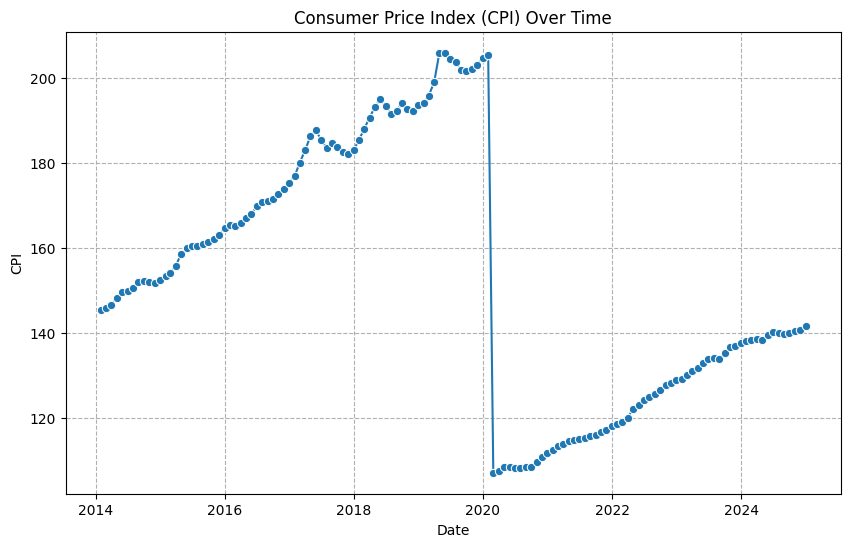

In [15]:
#Spot trends and Patterns
plt.figure(figsize=(10, 6))
sns.lineplot(data=cpi_df, x='DATE', y='OVERALL CPI', marker='o')
plt.title('Consumer Price Index (CPI) Over Time')
plt.xlabel('Date')
plt.ylabel('CPI')
plt.grid(True, linestyle='--')
plt.show()

The graph shows a sharp drop around 2020 this is explained by the economic shock caused by COVID and the lockdown around the world.

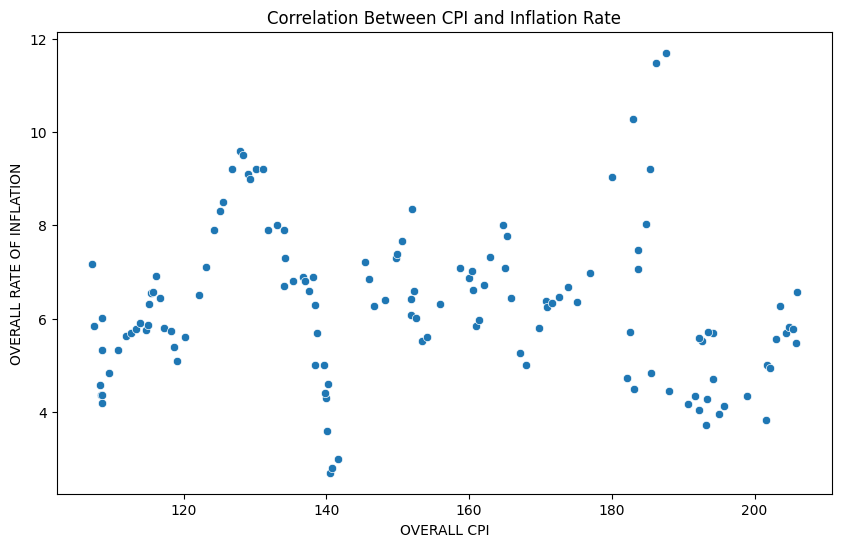

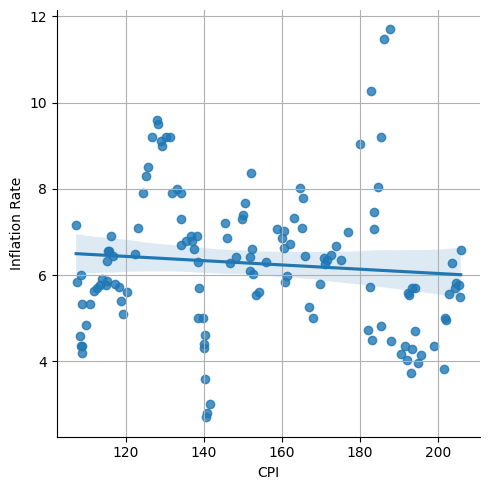

In [23]:
#Plot correlation between CPI and Inflation Rate
plt.figure(figsize=(10,6))
plt.title('Correlation Between CPI and Inflation Rate')
sns.scatterplot(data=cpi_df,x='OVERALL CPI', y='OVERALL RATE OF INFLATION')
sns.lmplot(data=cpi_df, x='OVERALL CPI', y='OVERALL RATE OF INFLATION')

plt.ylabel('Inflation Rate')
plt.xlabel('CPI')
plt.grid(True)
plt.tight_layout()
plt.show()

The regression line shows a slight negative slope indicating a weak negative linear relationship between CPI and Inflation rate in this dataset.
As CPI increases inflation rate tends to slightly decrease.

Modelling Phase

Forecasting Future CPI using Historical data.

In [25]:
pip install statsmodels

In [27]:
#import statsmodels

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

We are going to model using the Holt-Winters Model.

It models using:


*   Level: The baseline value
*   Trend: Long-term upward or downward movement
*   Seasonality: Repeating patterns







In [28]:
# Fit the model (monthly data = 12 periods in a year)
model = ExponentialSmoothing(
    cpi_df['OVERALL CPI'],
    trend = 'add',
    seasonal = 'add',
    seasonal_periods=12
).fit()

<ipython-input-31-a6700edd5ee5>:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(start=cpi_df['DATE'].max(), periods=12, freq='M'),forecast, label='Forecast CPI')


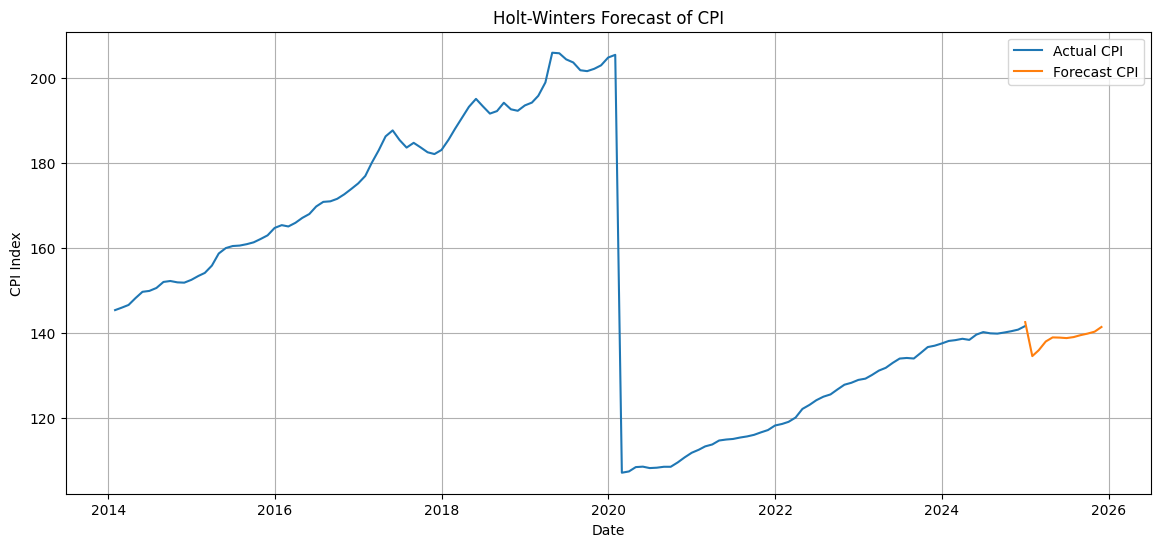

In [31]:
# Forecast for 12 future months

forecast = model.forecast(12)

# Plot actual + forecast
plt.figure(figsize=(14,6))
plt.plot(cpi_df['DATE'], cpi_df['OVERALL CPI'], label='Actual CPI')
plt.plot(pd.date_range(start=cpi_df['DATE'].max(), periods=12, freq='M'),forecast, label='Forecast CPI')
plt.title('Holt-Winters Forecast of CPI')
plt.xlabel('Date')
plt.ylabel('CPI Index')
plt.legend()
plt.grid(True)
plt.show()

The model reveals that if nothing drastic changes we expect CPI to rise modestly within the next 12 months.

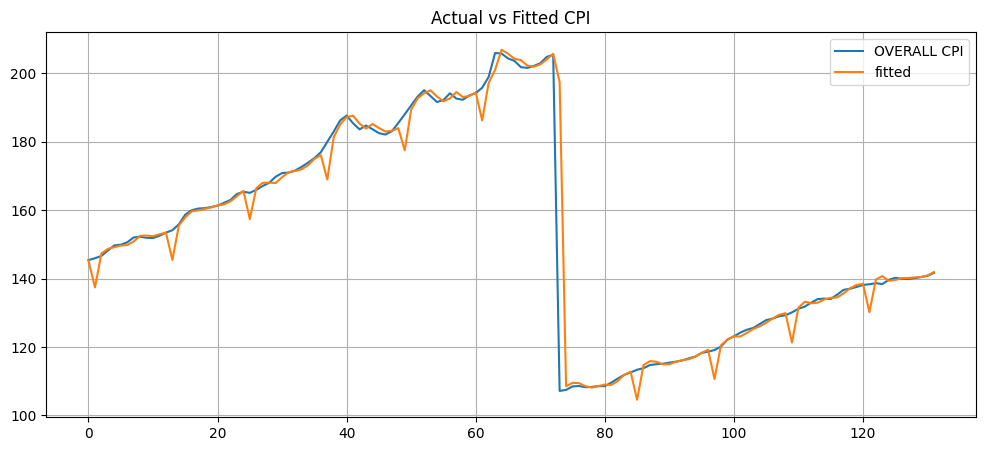

In [32]:
# Plot fitted values vs actual
cpi_df['fitted'] = model.fittedvalues

cpi_df[['OVERALL CPI', 'fitted']].plot(figsize=(12,5), title='Actual vs Fitted CPI')
plt.grid(True)

The Holt-Winter's model is a good fit overall